# 인공지능수학 3주차 — 선형회귀: 모델과 손실함수

**강의 시간:** 75분 (이론 50분 + 익히기 25분)

**지난 주 복습:** 예측값은 $\hat{y} = \mathbf{w}^T\mathbf{x}$ — 가중치와 입력의 내적  
**이번 주 질문:** 좋은 $\mathbf{w}$란 무엇인가? 어떻게 측정하는가?

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

---
# 🪄 Aha! — 먼저 결과부터

아파트 가격 회귀 문제를 다루려면 여러가지 특성(면적, 층수, 지역, 교통 등)과 집값을 직접 조사해야 합니다. 그러나 문제를 간단히 하기 위해 우리는 가상의 데이터를 생성하여 진행하겠습니다. $w$와 $b$를 임의로 지정하고, 노이즈를 추가해 아파트 면적과 집값 데이터를 만듭니다.

선형회귀란 면적과 집값 데이터를 통해 $w$와 $b$를 알아내는 것입니다.

파라미터 $w$와 $b$를 바꿔가며 **손실(loss)** 이 어떻게 변하는지 보겠습니다.

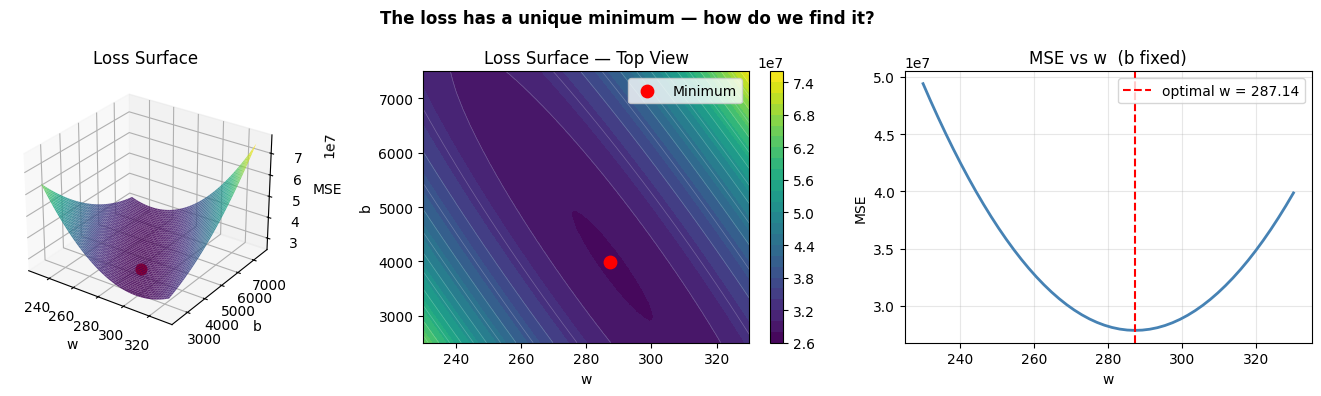

In [5]:
# Generate apartment data
n = 40
np.random.seed(42)
area  = np.random.uniform(30, 130, n)
price = 280 * area + 5000 + np.random.randn(n) * 6000   # 280*area + 5000, 40개 데이터

# Compute MSE over a grid of (w, b) values
w_vals = np.linspace(280-50, 280+50, 50)  # (280-50, 280+50) 구간을 50개로 균등 분할
b_vals = np.linspace(5000-2500, 5000+2500, 10000)
W, B   = np.meshgrid(w_vals, b_vals) # (w, b) 2D 평면 50*10,000=500,000개 w좌표, b좌표 생성
MSE    = np.array([[np.mean((w * area + b - price) ** 2)
                    for w, b in zip(wr, br)]
                   for wr, br in zip(W, B)])   # 500,000개 w[ , ] b[ , ] 각각에 대해 40개 데이터의 MSE 구함. MSE 결과도 2D 배열.

min_idx        = np.unravel_index(MSE.argmin(), MSE.shape)  # 640개 중 최소값을 갖는 인덱스를 argmin이 1D로 구했다가 unravel_index이 다시 2D로 변환
w_opt, b_opt   = W[min_idx], B[min_idx]   # 500,000개 중 최소값을 갖는 2D 인덱스를 이용해 최적의 w, b 각각 추출

fig = plt.figure(figsize=(14, 4))

# 3D bowl
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(W, B, MSE, cmap='viridis', alpha=0.85, linewidth=0)
ax1.scatter([w_opt], [b_opt], [MSE[min_idx]], color='red', s=60, zorder=5)
ax1.set_xlabel('w'); ax1.set_ylabel('b'); ax1.set_zlabel('MSE')
ax1.set_title('Loss Surface')
ax1.view_init(elev=28, azim=-55)

# Contour map
ax2 = fig.add_subplot(132)
cp  = ax2.contourf(W, B, MSE, levels=30, cmap='viridis')
ax2.contour(W, B, MSE, levels=15, colors='white', alpha=0.25, linewidths=0.5)
ax2.scatter([w_opt], [b_opt], color='red', s=80, zorder=5, label='Minimum')
plt.colorbar(cp, ax=ax2)
ax2.set_xlabel('w'); ax2.set_ylabel('b')
ax2.set_title('Loss Surface — Top View')
ax2.legend()

# 1-D slice
ax3 = fig.add_subplot(133)
mse_w = [np.mean((w * area + b_opt - price) ** 2) for w in w_vals]
ax3.plot(w_vals, mse_w, color='steelblue', linewidth=2)
ax3.axvline(w_opt, color='red', linestyle='--',
            label=f'optimal w = {w_opt:.2f}')
ax3.set_xlabel('w'); ax3.set_ylabel('MSE')
ax3.set_title('MSE vs w  (b fixed)')
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.suptitle('The loss has a unique minimum — how do we find it?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# meshgrid = 1D 축 배열들 → “격자점 좌표표”로 복제해서 2D로 만드는 함수
ws = [10, 20, 30, 40]   # w축 값들
bs = [1, 2]         # b축 값들

Ws, Bs = np.meshgrid(ws, bs)
print(Ws)
print(Bs)

[[10 20 30 40]
 [10 20 30 40]]
[[1 1 1 1]
 [2 2 2 2]]


In [12]:
# 리스크 컴프리헨션 list comprehension
w2 = [(w**2) for w in ws]
print(w2)
wm = [np.mean((w**2)) for w in Ws]
print(wm)

[100, 400, 900, 1600]
[np.float64(750.0), np.float64(750.0)]


> ❓ **이 그릇 모양의 최저점을 어떻게 찾을까요?**
>
> 오늘은 이 "그릇"이 어떻게 만들어지는지를 배웁니다.  
> **다음 주**에는 이 최저점을 수학적으로 찾는 방법 — **경사하강법**을 배웁니다.

---
# Part 1. 선형회귀 모델

## 1-1. 모델 정의

입력 특성이 $n$개일 때 선형회귀 모델은:

$$\hat{y} = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$

편향 트릭(2주차)으로 간단히:

$$\hat{y} = \mathbf{w}^T \mathbf{x}, \quad \mathbf{x} \leftarrow \begin{bmatrix} x_1 \\ \vdots \\ x_n \\ 1 \end{bmatrix}, \quad \mathbf{w} \leftarrow \begin{bmatrix} w_1 \\ \vdots \\ w_n \\ b \end{bmatrix}$$

$m$개 샘플을 한 번에:

$$\hat{\mathbf{y}} = X\mathbf{w}, \quad X \in \mathbb{R}^{m \times (n+1)}, \quad \mathbf{w} \in \mathbb{R}^{n+1}$$

## 1-2. 잔차(Residual)

예측값과 실제값의 차이를 **잔차**라고 합니다.

$$e_i = y_i - \hat{y}_i$$

- $e_i > 0$: 예측이 실제보다 낮음 (과소 예측)
- $e_i < 0$: 예측이 실제보다 높음 (과대 예측)
- $e_i = 0$: 완벽한 예측

좋은 모델 = 잔차가 전반적으로 작은 모델

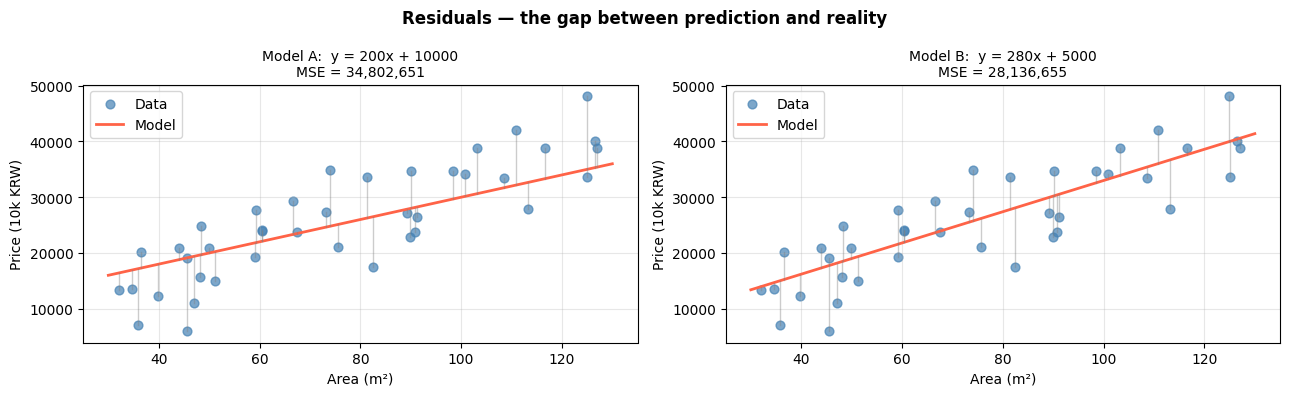

In [6]:
# Visualize residuals for two different models
w_guess, b_guess = 200.0, 10000.0   # rough guess
w_good,  b_good  = 280.0,  5000.0   # closer to truth

x_line = np.linspace(30, 130, 100)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (w, b, title) in zip(axes, [
    (w_guess, b_guess, f'Model A:  y = {w_guess:.0f}x + {b_guess:.0f}'),
    (w_good,  b_good,  f'Model B:  y = {w_good:.0f}x + {b_good:.0f}'),
]):
    y_hat = w * area + b
    residuals = price - y_hat

    ax.scatter(area, price, color='steelblue', alpha=0.7, s=40, label='Data')
    ax.plot(x_line, w * x_line + b, color='tomato', linewidth=2, label='Model')

    # Draw residual lines
    for xi, yi, ri in zip(area, price, residuals):
        ax.plot([xi, xi], [yi, yi - ri], color='gray', alpha=0.4, linewidth=1)

    mse = np.mean(residuals ** 2)
    ax.set_title(f'{title}\nMSE = {mse:,.0f}', fontsize=10)
    ax.set_xlabel('Area (m²)')
    ax.set_ylabel('Price (10k KRW)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Residuals — the gap between prediction and reality',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
# Part 2. 손실함수 (Loss Function)

## 2-1. 왜 잔차 합을 직접 쓰지 않는가

잔차를 그냥 더하면 양수와 음수가 상쇄됩니다.

$$\sum_{i=1}^m e_i = \sum_{i=1}^m (y_i - \hat{y}_i) \quad \leftarrow \text{상쇄 문제}$$

예시: 잔차가 $[+100, -100]$이면 합 = 0 이지만 예측이 좋은 게 아닙니다.

**해결책:** 제곱합을 사용한다.

## 2-2. MSE (Mean Squared Error)

$$\mathcal{L}(\mathbf{w}) = \text{MSE} = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2 = \frac{1}{m} \|\mathbf{y} - \hat{\mathbf{y}}\|^2$$

- $m$: 샘플 수
- $\|\cdot\|$: L2 norm (1주차에서 배운 벡터의 길이)
- 제곱이므로 항상 $\mathcal{L} \geq 0$
- 큰 잔차에 **더 큰 패널티** (제곱의 특성)

## 2-3. MSE의 행렬 표현 ⭐

$$\mathcal{L}(\mathbf{w}) = \frac{1}{m}(X\mathbf{w} - \mathbf{y})^T(X\mathbf{w} - \mathbf{y})$$

전개하면:

$$= \frac{1}{m}(\mathbf{w}^T X^T X \mathbf{w} - 2\mathbf{y}^T X \mathbf{w} + \mathbf{y}^T\mathbf{y})$$

$\mathbf{w}$에 대한 **이차식** → Aha에서 본 그릇 모양의 수학적 이유입니다.

| 표현 |&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;  식  &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;   |
|------|-----------|
| 스칼라 합 | $\frac{1}{m}\sum_i(y_i - \hat{y}_i)^2$ |
| 벡터 | $\frac{1}{m}\|\mathbf{y} - X\mathbf{w}\|^2$ |
| 행렬 | $\frac{1}{m}(X\mathbf{w}-\mathbf{y})^T(X\mathbf{w}-\mathbf{y})$ |

In [7]:
def mse(y, y_hat):
    """Mean Squared Error — three equivalent implementations."""
    m = len(y)
    # Method 1: scalar sum
    loss1 = sum((yi - yhi)**2 for yi, yhi in zip(y, y_hat)) / m
    # Method 2: NumPy vectorized
    loss2 = np.mean((y - y_hat) ** 2)
    # Method 3: L2 norm squared
    loss3 = np.linalg.norm(y - y_hat) ** 2 / m
    return loss1, loss2, loss3

y_hat_A = w_guess * area + b_guess
y_hat_B = w_good  * area + b_good

l1, l2, l3 = mse(price, y_hat_A)
print(f"Model A MSE: {l1:,.0f}  {l2:,.0f}  {l3:,.0f}  (all equal: {np.allclose([l1,l2,l3], l1)})")

l1, l2, l3 = mse(price, y_hat_B)
print(f"Model B MSE: {l1:,.0f}  {l2:,.0f}  {l3:,.0f}  (all equal: {np.allclose([l1,l2,l3], l1)})")

Model A MSE: 34,802,651  34,802,651  34,802,651  (all equal: True)
Model B MSE: 28,136,655  28,136,655  28,136,655  (all equal: True)


## 2-4. 왜 MSE가 그릇 모양인가

단순화를 위해 특성 1개, 편향 없음: $\hat{y}_i = w x_i$

$$\mathcal{L}(w) = \frac{1}{m}\sum_{i=1}^m (y_i - wx_i)^2$$

전개하면:

$$= \frac{1}{m}\sum_i (y_i^2 - 2y_i x_i w + x_i^2 w^2)
= \underbrace{\left(\frac{1}{m}\sum_i x_i^2\right)}_{A>0} w^2
  - \underbrace{\left(\frac{2}{m}\sum_i x_i y_i\right)}_{B} w
  + \underbrace{\left(\frac{1}{m}\sum_i y_i^2\right)}_{C}$$

이것은 $w$에 대한 **이차함수** $Aw^2 - Bw + C$ 이고, $A > 0$이므로 **아래로 볼록** → 그릇 모양  
→ **최솟값이 반드시 하나** 존재합니다. (다음 주에 이 최솟값을 찾습니다)

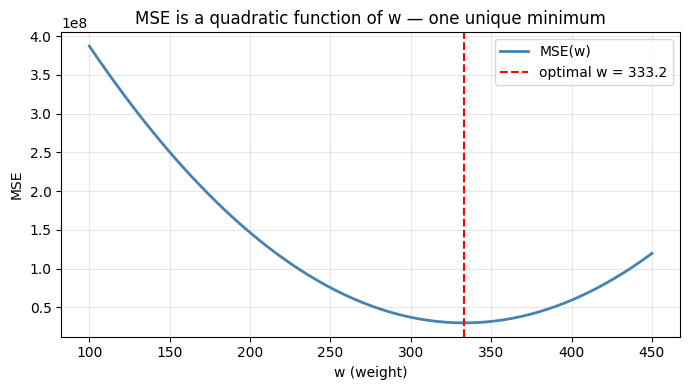

Optimal w (analytic) = B/(2A) = 333.17


In [9]:
# Visualize: MSE as a function of w (simplified: single feature, no bias)
w_range = np.linspace(100, 450, 200)
mse_vals = [np.mean((price - w * area) ** 2) for w in w_range]

# Compute coefficients A, B, C
A = np.mean(area ** 2)
B = 2 * np.mean(area * price)
C = np.mean(price ** 2)
w_opt_analytic = B / (2 * A)   # vertex of parabola

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(w_range, mse_vals, color='steelblue', linewidth=2, label='MSE(w)')
ax.axvline(w_opt_analytic, color='red', linestyle='--',
           label=f'optimal w = {w_opt_analytic:.1f}')
ax.set_xlabel('w (weight)')
ax.set_ylabel('MSE')
ax.set_title('MSE is a quadratic function of w — one unique minimum')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal w (analytic) = B/(2A) = {w_opt_analytic:.2f}")

---
# Part 3. 최적 $\mathbf{w}$ 구하기 — 맛보기

## 3-1. 정규방정식 (Normal Equation)

MSE를 $\mathbf{w}$에 대해 미분하고 0으로 놓으면 (미분은 4주차에 자세히):

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 0 \quad \Longrightarrow \quad \mathbf{w}^* = (X^T X)^{-1} X^T \mathbf{y}$$

이것이 **정규방정식**입니다. 수식 한 줄로 최적해를 구할 수 있습니다.

> **하지만 왜 경사하강법이 필요한가?**  
> $(X^TX)^{-1}$을 계산하는 비용이 $O(n^3)$입니다.  
> 특성이 1만 개이면 계산이 사실상 불가능합니다.  
> 실제 딥러닝에서 특성은 수백만 개 이상 → **경사하강법이 필수**

Normal equation solution:
  w = 288.03  (true: 280)
  b = 3921.92  (true: 5000)
  MSE = 27,860,275


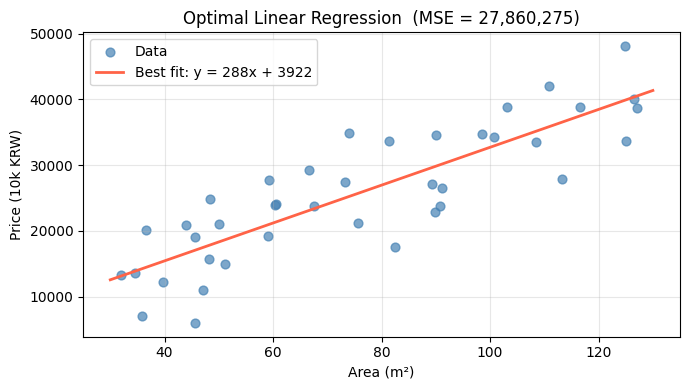

In [10]:
# Normal equation — exact solution in one line
X_mat = np.column_stack([area, np.ones(n)])   # shape (40, 2)

# w* = (X^T X)^{-1} X^T y
w_star = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ price
w_val, b_val = w_star

y_star = X_mat @ w_star
mse_star = np.mean((y_star - price) ** 2)

print(f"Normal equation solution:")
print(f"  w = {w_val:.2f}  (true: 280)")
print(f"  b = {b_val:.2f}  (true: 5000)")
print(f"  MSE = {mse_star:,.0f}")

# Visualize optimal fit
x_line = np.linspace(30, 130, 100)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(area, price, color='steelblue', alpha=0.7, s=40, label='Data')
ax.plot(x_line, w_val * x_line + b_val, color='tomato', linewidth=2,
        label=f'Best fit: y = {w_val:.0f}x + {b_val:.0f}')
ax.set_xlabel('Area (m²)')
ax.set_ylabel('Price (10k KRW)')
ax.set_title(f'Optimal Linear Regression  (MSE = {mse_star:,.0f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# ✏️ 익히기 활동 (25분)

---

## 활동 1. MSE 직접 계산 (7분)

예측값과 실제값이 아래와 같을 때 MSE를 손으로 먼저 계산하고, 코드로 확인하세요.

$$\mathbf{y} = \begin{bmatrix} 3 \\ 5 \\ 2 \\ 8 \end{bmatrix}, \quad \hat{\mathbf{y}} = \begin{bmatrix} 2.5 \\ 5.5 \\ 3.0 \\ 7.0 \end{bmatrix}$$

**손으로:** 각 잔차 → 잔차 제곱 → 평균

In [ ]:
# Activity 1: compute MSE
y     = np.array([3.0, 5.0, 2.0, 8.0])
y_hat = np.array([2.5, 5.5, 3.0, 7.0])

# TODO: compute MSE
loss = ______

print(f"MSE = {loss:.4f}")   # expected: 0.625

## 활동 2. 두 모델 비교 (8분)

같은 데이터에서 두 모델의 MSE를 계산하고 어느 쪽이 더 나은지 확인하세요.

In [ ]:
# Activity 2: compare two models
# area: already defined above

# Model A
w_A, b_A = 250.0, 8000.0
# Model B
w_B, b_B = 300.0, 3000.0

# TODO: compute predictions and MSE for both models
y_hat_A = ______
y_hat_B = ______
mse_A   = ______
mse_B   = ______

print(f"Model A MSE: {mse_A:,.0f}")
print(f"Model B MSE: {mse_B:,.0f}")
print(f"Better model: {'A' if mse_A < mse_B else 'B'}")

## 활동 3. 🐛 버그 찾기 (10분)

아래 코드는 MSE를 계산하는데 결과가 이상합니다.  
실행 전에 눈으로 버그 **2개**를 찾아보세요.

In [ ]:
# 🐛 Buggy MSE implementation — find 2 bugs before running

y     = np.array([3.0, 5.0, 2.0, 8.0])
y_hat = np.array([2.5, 5.5, 3.0, 7.0])

# Bug 1: residuals
residuals = y_hat - y          # ← sign doesn't matter for MSE, but check anyway

# Bug 2: squaring
squared = residuals ** 2

# Bug 3: mean — is this right?
loss = squared.sum()           # ← missing something

print(f"MSE = {loss:.4f}")   # should be 0.625, not 2.5

In [ ]:
# ✅ Fixed version
residuals = ______
squared   = ______
loss      = ______

print(f"MSE = {loss:.4f}")   # expected: 0.625

---
# 📋 오늘 배운 것 체크리스트

- [ ] 선형회귀 모델 $\hat{\mathbf{y}} = X\mathbf{w}$의 구조를 안다
- [ ] 잔차(residual)의 의미를 설명할 수 있다
- [ ] MSE 공식을 세 가지 표현(합, 벡터, 행렬)으로 쓸 수 있다
- [ ] MSE가 $\mathbf{w}$의 이차함수라서 그릇 모양임을 안다
- [ ] 정규방정식 $\mathbf{w}^* = (X^TX)^{-1}X^T\mathbf{y}$의 의미를 안다
- [ ] 정규방정식보다 경사하강법이 필요한 이유를 설명할 수 있다

---
# 💭 생각해볼 질문

1. MSE 대신 잔차의 절댓값 평균(MAE)을 쓰면 어떤 차이가 생길까요? 어떤 것이 더 좋을까요?
2. 그릇 모양이 아니라 여러 개의 골짜기가 있는 손실 함수는 어떤 문제를 만들어낼까요?
3. 정규방정식으로 구한 $\mathbf{w}^*$와 경사하강법으로 구한 $\mathbf{w}$는 같은 값으로 수렴할까요?

---
# 🤖 LLM 파트너 가이드

**① MSE 깊이 이해하기:**
```
MSE 대신 잔차 제곱의 합(SSE)이나 절댓값 평균(MAE)을 쓰는 경우도 있다고 하는데,
세 손실함수의 수학적 차이와 각각 언제 쓰는 게 유리한지 예시와 함께 설명해줘.
```

**② 정규방정식 유도:**
```
MSE = (1/m)||Xw - y||^2 를 w에 대해 미분해서
정규방정식 w* = (X^T X)^{-1} X^T y 를 유도하는 과정을
단계별로 보여줘. 행렬 미분을 처음 배우는 학생 수준으로.
```

**③ 다음 주 예습:**
```
y = x^2 - 4x + 5 의 최솟값을 미분으로 구하는 과정을 설명해줘.
이게 경사하강법과 어떻게 연결되는지도 알려줘.
```

---
# ➡️ 다음 주 예고

**3주차: 경사하강법 — 최솟값을 찾아가는 법**

오늘 만든 그릇 모양 손실 함수의 **최저점**을 어떻게 수학적으로 찾는지 배웁니다.  
핵심 도구: **미분** — "지금 이 위치에서 어느 방향으로 내려가야 하는가"